In [1]:
import os
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.backends.backend_pdf import PdfPages

import numpy as np

from pybaselines import Baseline, utils

import lmfit as lm
from lmfit import Model, Parameters, Parameter, report_fit, minimize, Minimizer

from scipy.signal import find_peaks

from assign_peaks import *

In [2]:
def process_files(txt_folder, num_files=60):
    files = [f for f in os.listdir(txt_folder) if not f.startswith('.')]
    files = files[:num_files]  # Vybereme pouze prvních 100 souborů
    df_tim, df_amp = [], []

    for f in files:
        print(f)
        txt_file = os.path.join(txt_folder, f)
        df_tim.append(pd.read_csv(txt_file, header=5, sep=",", usecols=[0]))
        df_amp.append(pd.read_csv(txt_file, header=5, sep=",", usecols=[1]))

    df_all_tim = pd.concat(df_tim, ignore_index=True, axis=1)
    df_all_amp = pd.concat(df_amp, ignore_index=True, axis=1)

    df_all_tim.to_csv('time.csv', sep=',')
    df_all_amp.to_csv('ampl.csv', sep=',')

    df_mean_tim = df_all_tim.mean(axis=1)
    df_mean_tim.to_csv('time_aver.txt', sep=',')
    df_mean_amp = df_all_amp.mean(axis=1)
    df_mean_amp.to_csv('ampl_aver.txt', sep=',')

    with open('averaged.txt', 'w') as f:
        pd.concat([df_mean_tim, df_mean_amp], axis=1).to_csv(f, sep=',')

    print('!Averaging finished!')

# Použití
txt_folder = 'C10pct'
process_files(txt_folder, num_files=600)

C2_2025-03-06_PS_K2_10proCO2_00000.txt
C2_2025-03-06_PS_K2_10proCO2_00001.txt
C2_2025-03-06_PS_K2_10proCO2_00002.txt
C2_2025-03-06_PS_K2_10proCO2_00003.txt
C2_2025-03-06_PS_K2_10proCO2_00004.txt
C2_2025-03-06_PS_K2_10proCO2_00005.txt
C2_2025-03-06_PS_K2_10proCO2_00006.txt
C2_2025-03-06_PS_K2_10proCO2_00007.txt
C2_2025-03-06_PS_K2_10proCO2_00008.txt
C2_2025-03-06_PS_K2_10proCO2_00009.txt
C2_2025-03-06_PS_K2_10proCO2_00010.txt
C2_2025-03-06_PS_K2_10proCO2_00011.txt
C2_2025-03-06_PS_K2_10proCO2_00012.txt
C2_2025-03-06_PS_K2_10proCO2_00013.txt
C2_2025-03-06_PS_K2_10proCO2_00014.txt
C2_2025-03-06_PS_K2_10proCO2_00015.txt
C2_2025-03-06_PS_K2_10proCO2_00016.txt
C2_2025-03-06_PS_K2_10proCO2_00017.txt
C2_2025-03-06_PS_K2_10proCO2_00018.txt
C2_2025-03-06_PS_K2_10proCO2_00019.txt
C2_2025-03-06_PS_K2_10proCO2_00020.txt
C2_2025-03-06_PS_K2_10proCO2_00021.txt
C2_2025-03-06_PS_K2_10proCO2_00022.txt
C2_2025-03-06_PS_K2_10proCO2_00023.txt
C2_2025-03-06_PS_K2_10proCO2_00024.txt
C2_2025-03-06_PS_K2_10pro

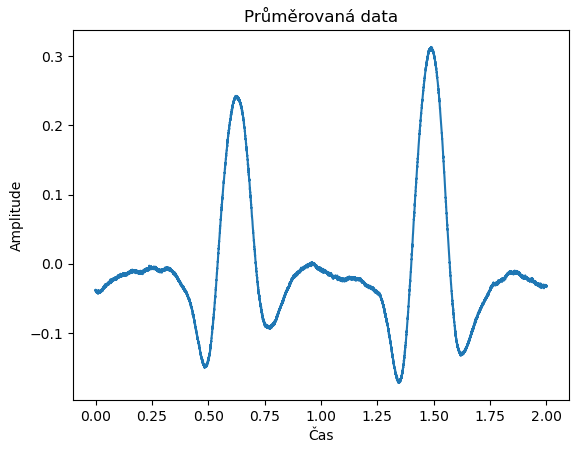

In [3]:
# Načtení průměrovaných dat ze souborů
df_mean_tim = pd.read_csv('time_aver.txt', sep=',', header= None, skiprows=1)
df_mean_amp = pd.read_csv('ampl_aver.txt', sep=',', header= None,  skiprows=1)
# Převod na numpy array
xs = df_mean_tim[1].to_numpy()
ys = df_mean_amp[1].to_numpy()

# Posun hodnot na x-ové ose o 2 sekundy
xs = xs + 2

# Vykreslení grafu
plt.plot(xs, ys)
plt.xlabel('Čas')
plt.ylabel('Amplitude')
plt.title('Průměrovaná data')
plt.show()

InputFile = 'averaged.txt'

In [4]:
#Number_of_Samples_per_Second
print(len(xs))
SpS = int(len(xs)/np.max(xs))
print("!Sampling rate of the datases is " + str(SpS) + " Samples/s!" )

10001
!Sampling rate of the datases is 5000 Samples/s!


In [5]:
Out1 = PdfPages('out2f_exp.pdf')
Out2 = PdfPages('out2f_fit.pdf')

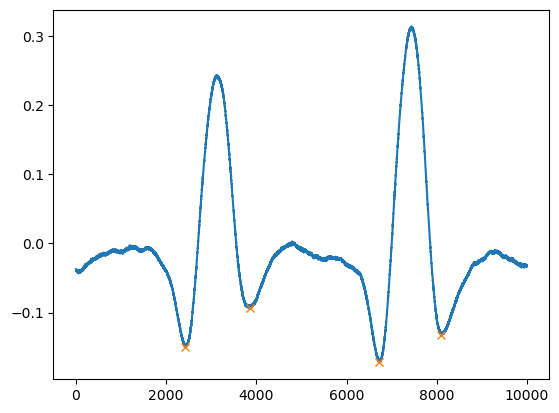

In [6]:
peaks, _ = find_peaks(-ys, height=0.05, distance=500, width=300)
np.diff(peaks)
plt.plot(ys)
plt.plot(peaks, ys[peaks], "x")
plt.show()

xpik = xs[peaks]
ypik = ys[peaks]

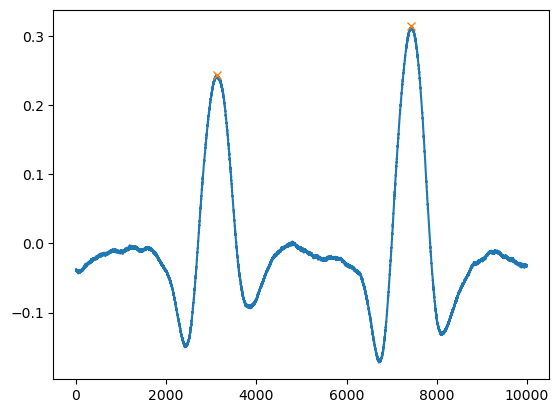

In [7]:

valleys, _ = find_peaks(ys, height=0.1, distance=500, width=250)
np.diff(valleys)
plt.plot(ys)
plt.plot(valleys, ys[valleys], "x")
plt.show()

xval = xs[valleys]
yval = ys[valleys]

In [8]:
#vytvoreni pole objektu peaku
peak_objects = AssignPeaks(xpik, xval, ypik, yval)
numpeak = len(peak_objects)
#overeni delek poli minim a maxim
VerifyPeaksLength(xpik, xval, peak_objects)
#vypsat
SavePeakSpectra(peak_objects, xs, ys, InputFile, 2)

Peaks matched/consistent definition!
Total number of peaks identified in 2f-WMS signal is: 2
Peak1 centered at: 0.6260972698333342(left minimum: 0.48309726983333245; right minimum: 0.7710972698333345)
Peak2 centered at: 1.4878972685333334(left minimum: 1.343497268533333; right minimum: 1.6186972685333332)


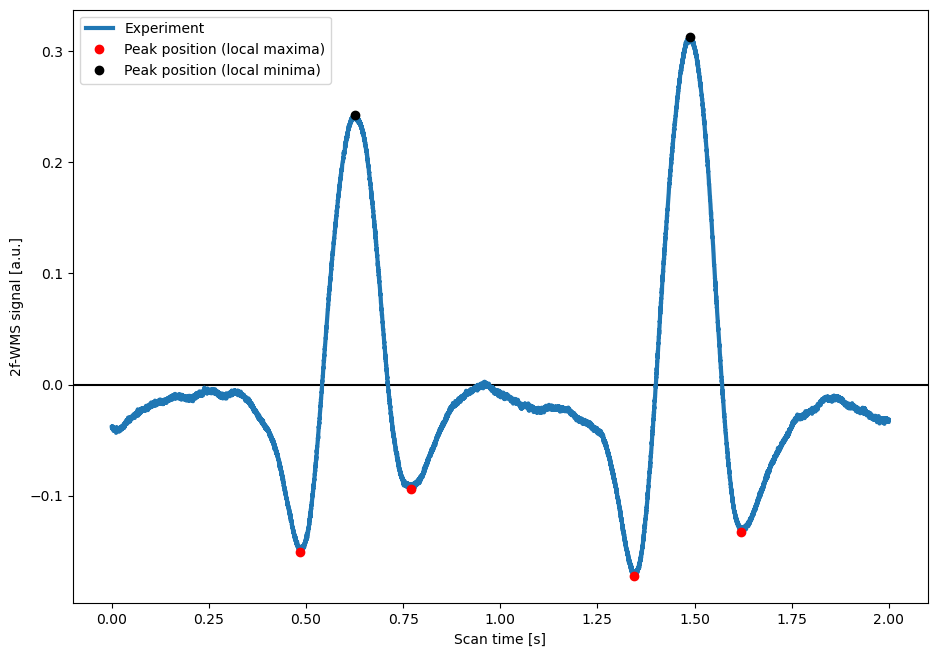

In [9]:
plt.figure(2) 
plt.axhline(0, color='k') 
line1, = plt.plot(xs, ys, linewidth=3, label='Experiment') 
point1, = plt.plot(xpik, ypik, 'ro', linewidth=5, label='Peak position (local maxima)') 
point2, = plt.plot(xval, yval, 'ko', linewidth=5, label='Peak position (local minima)') 
plt.legend(handler_map={line1: HandlerLine2D(numpoints=1)}) 
plt.xlabel(r"Scan time [s]") 
plt.ylabel(r"2f-WMS signal [a.u.]") 
plt.tight_layout() 
a4 = plt.gcf() 
a4.set_size_inches([10,7]) 
a4.savefig(Out1, format='pdf') 
plt.show() 
Out1.close()

In [10]:
def lorentzianA(xs, a0, a1, a2):
    return a0/(np.pi*a2*(1+((xs-a1)/a2)**2))

def D2lorentzianA(xs, a0, a1, a2):
    return -2*a0*a2*(a2**2-3*(a1-xs)**2)/(np.pi*(a2**2+(a1-xs)**2)**3)

def gaussianA(xs, a0, a1, a2):
    sigma = a2/np.sqrt(2*np.log(2))
    return a0/(sigma*np.sqrt(2*np.pi))*np.exp(-(xs-a1)**2/(2*sigma**2))

def D2gaussianA(xs, a0, a1, a2):
    sigma = np.sqrt(2*np.log(2))*a2
    poly2 = ((xs-a1)**2-sigma**2)/sigma**4
    return poly2*a0/(sigma*np.sqrt(2*np.pi))*np.exp(-(xs-a1)**2/(2*sigma**2))

In [11]:
result=[None]*numpeak
par=[None]*numpeak
resdata=[None]*numpeak
ofst=[None]*numpeak
minner=[None]*numpeak
res2ult=[None]*numpeak
fin2ual=[None]*numpeak
res2data=[None]*numpeak
par2am=[None]*numpeak
gabor2=[None]*numpeak
gabor4=[None]*numpeak
gabor6=[None]*numpeak
gabor8=[None]*numpeak
gabor10=[None]*numpeak

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 2022
    # data points      = 4294
    # variables        = 3
    chi-square         = 2.44994065
    reduced chi-square = 5.7095e-04
    Akaike info crit   = -32065.5003
    Bayesian info crit = -32046.4054
    R-squared          = 0.93245436
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    a0: -0.00131007 (init = 0.242604)
    a1:  0.62620258 (init = 0.1988973)
    a2:  0.14331778 (init = 0.17172)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 152
    # data points      = 4294
    # variables        = 14
    chi-square         = 0.08103897
    reduced chi-square = 1.8934e-05
    Akaike info crit   = -46681.2696
    Bayesi

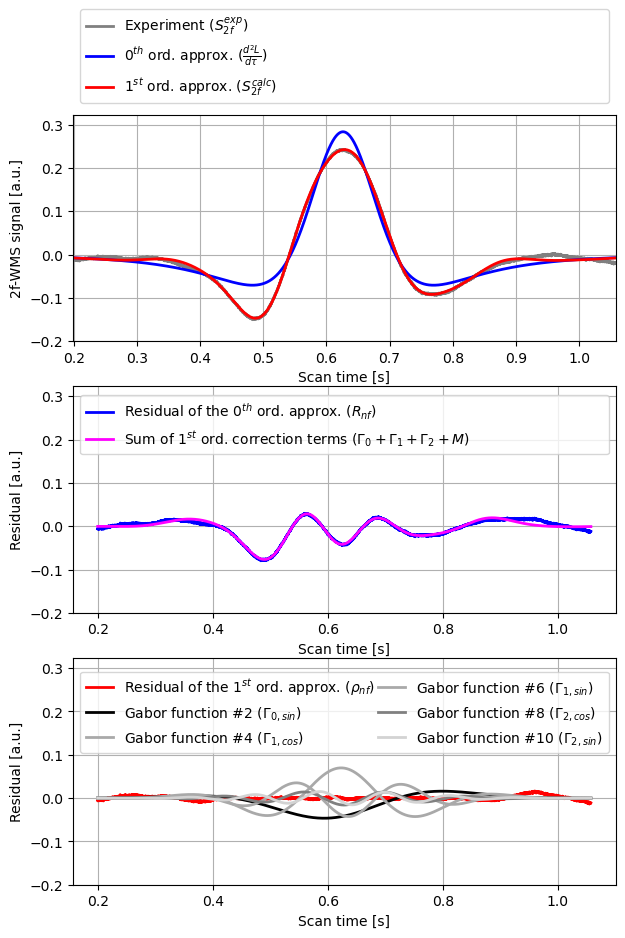

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 1674
    # data points      = 4229
    # variables        = 3
    chi-square         = 2.85719432
    reduced chi-square = 6.7610e-04
    Akaike info crit   = -30865.1955
    Bayesian info crit = -30846.1463
    R-squared          = 0.95148793
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    a0: -0.00176768 (init = 0.3133746)
    a1:  1.48640266 (init = 1.059297)
    a2:  0.14595464 (init = 0.16912)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 214
    # data points      = 4229
    # variables        = 14
    chi-square         = 0.04229560
    reduced chi-square = 1.0035e-05
    Akaike info crit   = -48659.6015
    Bayesi

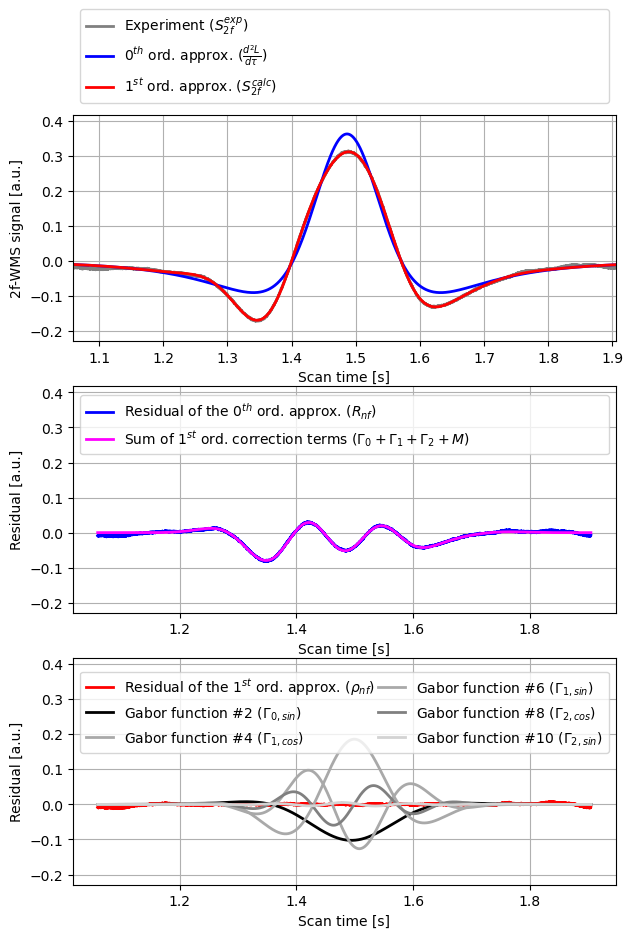

In [12]:
for i in range(1,numpeak+1):
    j=i-1
    
    InputFilePeaks = InputFile.replace(".txt", '_Peak') + str(i) + '.txt'
    Dataset = np.loadtxt(InputFilePeaks, skiprows= 0 + 1 + 2 + 3 + 4 , delimiter=',')
    x = Dataset[:, 0]
    y = Dataset[:, 1]

    Out3i = PdfPages('out_peakfit' + str(i) + '.pdf')
    
    params = lm.Parameters()
    params.add('a0', value=np.maximum(np.abs(np.amax(-y)),np.abs(np.amin(-y))), min=10*np.amin(-y), max=10*np.amax(-y))
    params.add('a1', value=np.amin(x)-(np.amax(x)-np.amin(x))/2, min=np.amin(x), max=np.amax(x))
    params.add('a2', value=(np.amax(x)-np.amin(x))/5, min=(np.amax(x)-np.amin(x))/10, max=(np.amax(x)-np.amin(x))/2)

    #model = lm.Model(D2gaussianA)
    model = lm.Model(D2lorentzianA)
     #result[j] = model.fit(y, params, x=x, method='leastsq')
    result[j] = model.fit(y, params, xs=x, method='differential_evolution')
    
    lm.report_fit(result[j])

    par[j] = result[j].best_values
   
    resdata[j] = result[j].residual
    
    #ofst[j] = np.mean(resdata[j])
    ofst[j] = 0
    
    def residual(params, x, resdata):
        "Gabor polynomial"
        params['a0']= Parameter(name = 'a0', value = par[j]['a0'] , vary = False)
        params['a1']= Parameter(name = 'a1', value = par[j]['a1'] , vary = False)
        params['a2']= Parameter(name = 'a2', value = par[j]['a2'] , vary = False)

        off = params['off']
        params['off']= Parameter(name = 'off', value = ofst[j] , vary = False)
        k2 = params['k2']
        k4 = params['k4']
        k6 = params['k6']

        k8 = params['k8']
        fi8 = params['fi8']
        
        k10 = params['k10']
        fi10 = params['fi10']

        fi6 = params['fi6']
        fi4 = params['fi4']
        fi2 = params['fi2']
        
        a0 = params['a0']
        a1 = params['a1']
        a2 = params['a2']

        w = params['w']

        sigma = a2/np.sqrt(2*np.log(2))
        gabor10 = np.cos(2*np.pi*(5/2)*(x-a1)/(2*a2)+fi10)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor8 = np.cos(2*np.pi*(4/2)*(x-a1)/(2*a2)+fi8)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor6 = np.sin(2*np.pi*(3/2)*(x-a1)/(2*a2)+fi6)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor4 = np.cos(2*np.pi*(2/2)*(x-a1)/(2*a2)+fi4)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor2 = np.sin(2*np.pi*(1/2)*(x-a1)/(2*a2)+fi2)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        
        return off + k10*gabor10 + k8*gabor8 + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
        #return off + k8*gabor8 + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
        #return off + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
    
        # create a set of Parameters
    
    params.add('off', min=-par[j]['a0'], max=par[j]['a0'], vary = False)
    params.add('k6', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k4', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k2', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k8', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k10', value=1.0, min=-50, max=50.0, vary = True)
    params.add('fi10', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi8', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi6', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi4', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi2', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('w', value=1.33, min= 1/3, max=5/3, vary = True)

       
    # do fit, here with leastsq model
    minner[j] = Minimizer(residual, params, fcn_args=(x, resdata[j]))
    res2ult[j] = minner[j].minimize(method = 'leastsq')
    # res2ult[j] = minner[j].minimize(method = 'differential_evolution')

    par2am[j] = res2ult[j].params
    #par2am[j].pretty_print()

    offj=par2am[j]['off'].value
    a0j=par2am[j]['a0'].value
    a1j=par2am[j]['a1'].value
    a2j=par2am[j]['a2'].value
    k6j=par2am[j]['k6'].value
    k4j=par2am[j]['k4'].value
    k2j=par2am[j]['k2'].value
    k8j=par2am[j]['k8'].value
    k10j=par2am[j]['k10'].value
    fi10j=par2am[j]['fi10'].value
    fi8j=par2am[j]['fi8'].value
    fi6j=par2am[j]['fi6'].value
    fi4j=par2am[j]['fi4'].value
    fi2j=par2am[j]['fi2'].value
    sigmaj = a2j/np.sqrt(2*np.log(2))
    wj=par2am[j]['w'].value

    gabor10[j] = np.sin(5*np.pi*(x-a1j)/(2*a2j)+fi10j)*k10j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor8[j] = np.cos(4*np.pi*(x-a1j)/(2*a2j)+fi8j)*k8j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor6[j] = np.sin(3*np.pi*(x-a1j)/(2*a2j)+fi6j)*k6j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor4[j] = np.cos(2*np.pi*(x-a1j)/(2*a2j)+fi4j)*k4j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor2[j] = np.sin(1*np.pi*(x-a1j)/(2*a2j)+fi2j)*k2j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))

    res2data[j] = res2ult[j].residual
    
    # calculate final result
    fin2ual[j] = resdata[j] + res2data[j]
    
    # write error report
    report_fit(res2ult[j])
    
    # write signal curve after Gabor fitting into csv file{x, result[j].best_fit-fin2ual[j]}
    # Create a DataFrame directly for each index j
    df = pd.DataFrame({'x': x, 'y': result[j].best_fit + fin2ual[j] + offj})
    # Write DataFrame to CSV file, naming it based on index j
    goutput_filename = f'goutput_{j+1}.csv'
    df.to_csv(goutput_filename, index=False)
    print(f'Data written to {goutput_filename} successfully.')
    
    fig2 = plt.figure(2)
    
    ax1=plt.subplot(311)
    line2, = plt.plot(x, y, 'grey', linewidth=2, label= r'Experiment ($S_{2f}^{exp}$)')
    line3, = plt.plot(x, result[j].best_fit, 'blue', linewidth=2, label= r'$0^{th}$ ord. approx. ($\frac{d^{2}L}{d\tau}$)')
    line3f, = plt.plot(x, result[j].best_fit+fin2ual[j], 'red', linewidth=2, label= r'$1^{st}$ ord. approx. ($S_{2f}^{calc}$)')
    plt.legend(handler_map={line1: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=1)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"2f-WMS signal [a.u.]")
    plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 1.33*np.amin(y), 1.33*np.amax(y),])
    plt.grid(True)

    ax2=plt.subplot(312, sharey=ax1)
    line4, = plt.plot(x, result[j].residual, 'blue',linewidth=2, label=r'Residual of the $0^{th}$ ord. approx. ($R_{nf}$)')
    line5, = plt.plot(x, fin2ual[j], 'magenta', linewidth=2, label=r'Sum of $1^{st}$ ord. correction terms ($\Gamma_0 + \Gamma_1 + \Gamma_2 + M$)')
    plt.legend(handler_map={line4: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,0.67,1,0.2), loc="lower left", mode="expand", ncol=1)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), -1.5*np.amax(result[j].residual), -2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    ax3=plt.subplot(313, sharey=ax1)
    line6, = plt.plot(x, -res2ult[j].residual, 'red',linewidth=2, label=r'Residual of the $1^{st}$ ord. approx. ($\rho_{nf}$)')
    line7, = plt.plot(x, gabor2[j], 'black',linewidth=2, label= r'Gabor function #2 ($\Gamma_{0,sin}$)')
    line8, = plt.plot(x, gabor4[j], 'darkgray',linewidth=2, label= r'Gabor function #4 ($\Gamma_{1,cos}$)')
    line9, = plt.plot(x, gabor6[j], 'darkgrey',linewidth=2, label=r'Gabor function #6 ($\Gamma_{1,sin}$)')
    line10, = plt.plot(x, gabor8[j], 'grey',linewidth=2, label=r'Gabor function #8 ($\Gamma_{2,cos}$)')
    line11, = plt.plot(x, gabor10[j], 'lightgrey',linewidth=2, label=r'Gabor function #10 ($\Gamma_{2,sin}$)')
    #line11, = plt.plot(x, -gabor2[j]-gabor4[j]-gabor6[j]-gabor8[j], 'm:',linewidth=4)
    plt.legend(handler_map={line6: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,0.55,1,0.2), loc="lower left", mode="expand", ncol=2)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 2.0*offj-1.5*np.amax(result[j].residual), 2.0*offj-2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    #plt.tight_layout()
    a4 = plt.gcf()
    a4.set_size_inches([7,10])
    a4.savefig(Out2, format='pdf')
    a4.savefig(Out3i, format='pdf')
    plt.show()

    Out3i.close()
    
Out2.close()

In [13]:
# g1_x, g1_y for peak g1 around 37
OutputFile1 = 'goutput_1.csv'
Dataset1 = np.loadtxt(OutputFile1, skiprows=1, delimiter=',')
g1_x = Dataset1[:, 0]
g1_y = Dataset1[:, 1]

# g2_x, g2_y for the second peak (you can specify the correct file or arrays)
OutputFile2 = 'goutput_2.csv'
Dataset2 = np.loadtxt(OutputFile2, skiprows=1, delimiter=',')
g2_x = Dataset2[:, 0]
g2_y = Dataset2[:, 1]

# Create new y array with zeros outside the range of the two peaks
goutput_y = np.zeros_like(xs)

# Set y-values for the first peak
goutput_y[(xs >= np.min(g1_x)) & (xs <= np.max(g1_x))] = g1_y[(g1_x >= np.min(g1_x)) & (g1_x <= np.max(g1_x))]

# Set y-values for the second peak
goutput_y[(xs >= np.min(g2_x)) & (xs <= np.max(g2_x))] = g2_y[(g2_x >= np.min(g2_x)) & (g2_x <= np.max(g2_x))]

# Save the new array to a CSV file if needed
goutput = np.column_stack((xs, goutput_y))
np.savetxt('goutput.csv', goutput, delimiter=',', header='x,y', comments='')

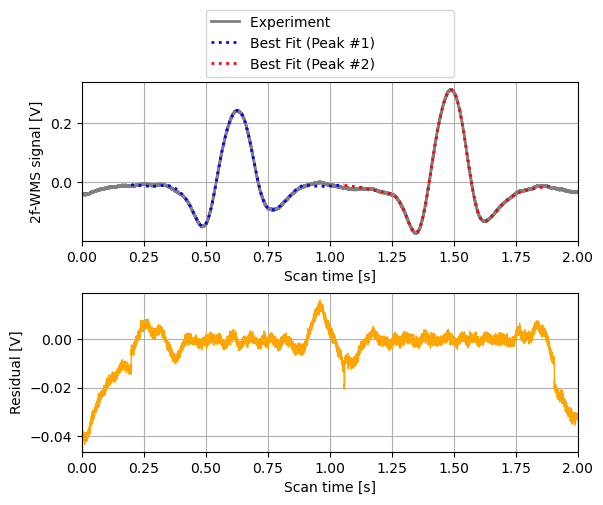

Peak 1:
  - Height of peak (h2f): 0.242603993999999
  - Amplitude of peak (a2f): 0.36473263233333175
Peak 2:
  - Height of peak (h2f): 0.3133745959999997
  - Amplitude of peak (a2f): 0.46576874366666554


In [14]:
fig4 = plt.figure(2)

ax1 = plt.subplot(211)
plt.plot(xs, ys, 'grey', linewidth=2,  label='Experiment                           ')
plt.plot(g1_x, g1_y, 'blue', linestyle="dotted", linewidth=2, label='Best Fit (Peak #1)')
plt.plot(g2_x, g2_y, 'red', linestyle="dotted", linewidth=2, label='Best Fit (Peak #2)')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.5), ncol=1)
plt.xlabel("Scan time [s]")
plt.ylabel("2f-WMS signal [V]")
plt.xlim([0, 2])
plt.grid(True)

ax2 = plt.subplot(212)
plt.plot(xs, ys-goutput_y, 'orange', linewidth=1)
#plt.plot(xs, ys-goutput_y, 'blue', linewidth=2, label='Residual (Experiment (w/o background subtraction) - Best Fit)')
#ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.33), ncol=1)
plt.xlabel("Scan time [s]")
plt.ylabel("Residual [V]")
plt.xlim([0, 2])
plt.grid(True)

# Adjust vertical space between subplots
fig4.subplots_adjust(hspace=0.33)

plt.show()

h2f_values = []  # Výšky od nuly
a2f_values = []  # Amplitudy

# Pro každý peak v poli peak_objects
for peak in peak_objects:
    h2f = peak.s2_max  # Výška od nuly
    a2f = peak.s2_ampl  # Amplituda

    h2f_values.append(h2f)
    a2f_values.append(a2f)

# Výpis výsledků
for i, (h2f, a2f) in enumerate(zip(h2f_values, a2f_values)):
    print(f"Peak {i+1}:")
    print(f"  - Height of peak (h2f): {h2f}")
    print(f"  - Amplitude of peak (a2f): {a2f}")

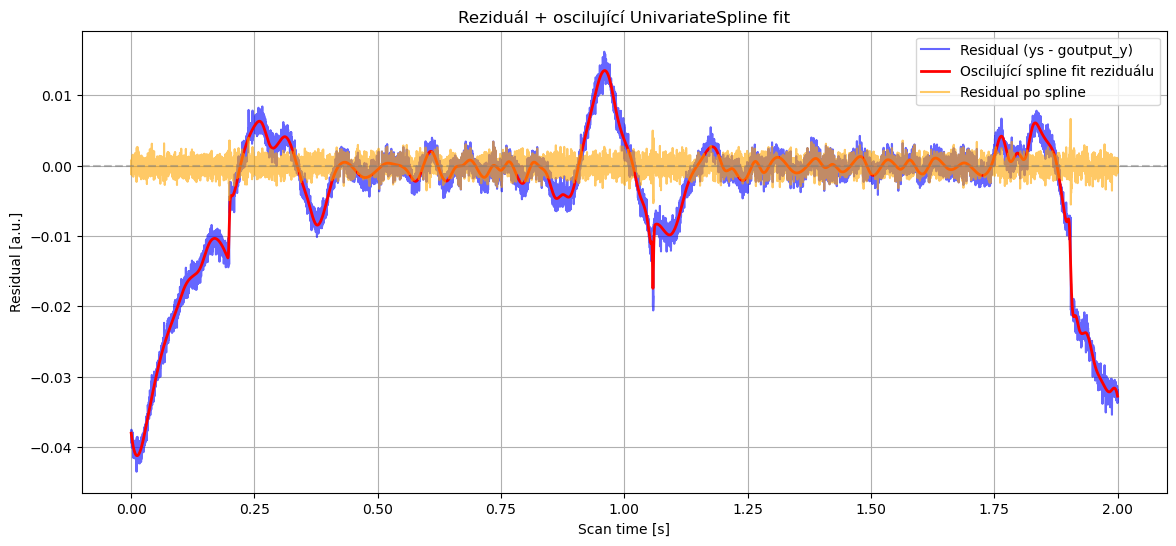

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# xs, ys, goutput_y už máš z předchozích kroků
xs = np.asarray(xs, dtype=float).flatten()
residual = ys - goutput_y

# ------------------------------------------------------------
# Oscilující UnivariateSpline fit na reziduál
# ------------------------------------------------------------

# menší smoothing → spline kopíruje oscilace
smoothing = 1e-2 * np.sum(residual**2)

res_spline = UnivariateSpline(xs, residual, s=smoothing)
res_fit = res_spline(xs)

# ------------------------------------------------------------
# Vizualizace
# ------------------------------------------------------------

plt.figure(figsize=(14,6))
plt.plot(xs, residual, label="Residual (ys - goutput_y)", color="blue", alpha=0.6)
plt.plot(xs, res_fit, label="Oscilující spline fit reziduálu", color="red", linewidth=2)
plt.plot(xs, residual-res_fit, label="Residual po spline", color="orange", alpha=0.6)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.title("Reziduál + oscilující UnivariateSpline fit")
plt.xlabel("Scan time [s]")
plt.ylabel("Residual [a.u.]")
plt.grid(True)
plt.legend()
plt.show()


Celkový RMS šumu: 0.0010397966303861941
RMS šumu – Peak 1: 0.0010233579270856473
RMS šumu – Peak 2: 0.0010342077376238432


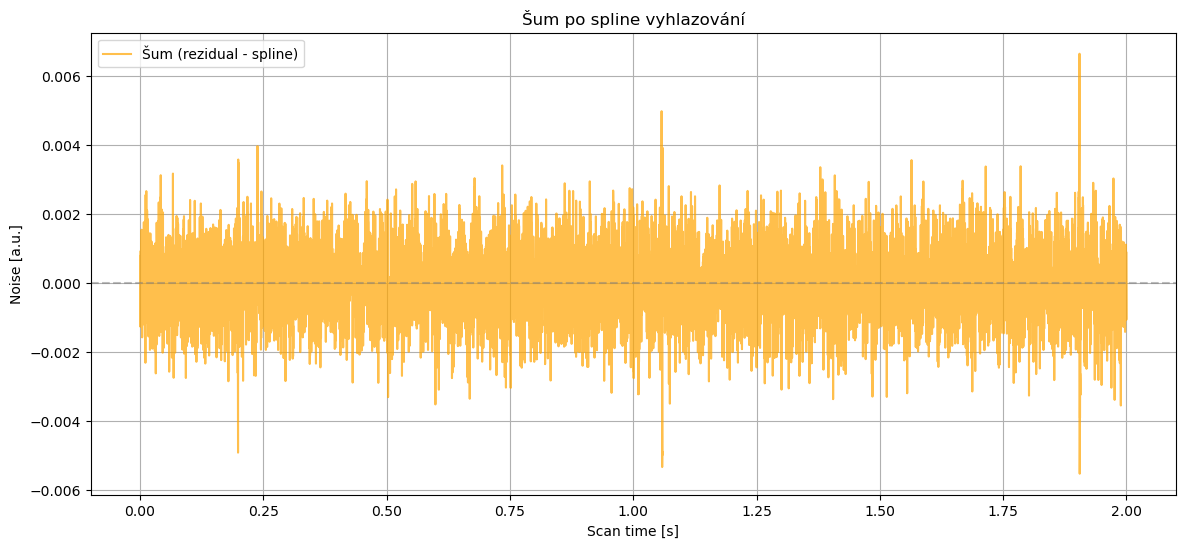

In [16]:
# ------------------------------------------------------------
# Šum po spline vyhlazení
# ------------------------------------------------------------
noise = residual - res_fit

# RMS šumu přes celý sken
noise_RMS = np.sqrt(np.mean(noise**2))
print("Celkový RMS šumu:", noise_RMS)

# ------------------------------------------------------------
# RMS šumu pro každý peak zvlášť
# ------------------------------------------------------------

# masky peaků (stejné jako pro g1_x, g2_x)
mask1 = (xs >= np.min(g1_x)) & (xs <= np.max(g1_x))
mask2 = (xs >= np.min(g2_x)) & (xs <= np.max(g2_x))

noise_RMS_p1 = np.sqrt(np.mean(noise[mask1]**2))
noise_RMS_p2 = np.sqrt(np.mean(noise[mask2]**2))

print("RMS šumu – Peak 1:", noise_RMS_p1)
print("RMS šumu – Peak 2:", noise_RMS_p2)

# ------------------------------------------------------------
# Vizualizace šumu
# ------------------------------------------------------------

plt.figure(figsize=(14,6))
plt.plot(xs, noise, label="Šum (rezidual - spline)", color="orange", alpha=0.7)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.title("Šum po spline vyhlazování")
plt.xlabel("Scan time [s]")
plt.ylabel("Noise [a.u.]")
plt.grid(True)
plt.legend()
plt.show()


⚠️ Asymetrie křídel: ratio = 0.750
⚠️ Asymetrie křídel: ratio = 0.878
Peak 1 edges: 0.33669726983333503 1.0176972685333343
Peak 2 edges: 1.147697268533333 1.8772972685333333
Baseline peak 1: y = -0.001615 * x + -0.009452
Baseline peak 2: y = 0.010222 * x + -0.032806


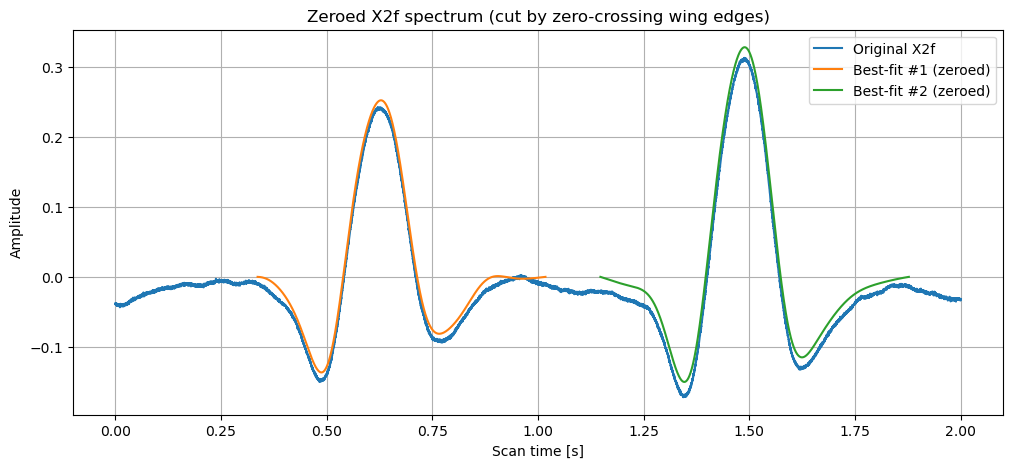

Zeroed spectrum prepared for saving.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ------------------------------------------------------------
# 1) Funkce: najde okraje křídel pomocí zero-crossing mezi
#    nejvyšším vrcholem a nejhlubším dolíčkem na každé straně
# ------------------------------------------------------------
def find_wing_edges(xs, res_fit, peak_x, mask, symmetry_tol=0.10):

    xs_m = xs[mask]
    r_m  = res_fit[mask]

    # vrcholy a dolíčky
    maxima_idx, _ = find_peaks(r_m)
    minima_idx, _ = find_peaks(-r_m)

    maxima_x = xs_m[maxima_idx]
    minima_x = xs_m[minima_idx]

    # průchody nulou
    zero_crossings = []
    for i in range(1, len(r_m)):
        if (r_m[i-1] > 0 and r_m[i] < 0) or (r_m[i-1] < 0 and r_m[i] > 0):
            zero_crossings.append(xs_m[i])
    zero_crossings = np.array(zero_crossings)

    # ------------------------------------------------------------
    # Funkce pro nalezení okraje na jedné straně
    # ------------------------------------------------------------
    def find_single_side(side):

        if side == 'right':
            side_mask = xs_m > peak_x
        else:
            side_mask = xs_m < peak_x

        xs_s = xs_m[side_mask]
        r_s  = r_m[side_mask]

        if len(xs_s) < 10:
            return np.nan

        # vrcholy a dolíčky na straně
        maxima_s = maxima_x[(maxima_x > xs_s.min()) & (maxima_x < xs_s.max())]
        minima_s = minima_x[(minima_x > xs_s.min()) & (minima_x < xs_s.max())]

        if len(maxima_s) == 0 or len(minima_s) == 0:
            return np.nan

        # nejvyšší vrchol a nejhlubší dolíček
        highest_peak = maxima_s[np.argmax(r_s[np.isin(xs_s, maxima_s)])]
        deepest_dip  = minima_s[np.argmin(r_s[np.isin(xs_s, minima_s)])]

        # průchody nulou mezi nimi
        candidates = zero_crossings[(zero_crossings > min(highest_peak, deepest_dip)) &
                                    (zero_crossings < max(highest_peak, deepest_dip))]

        if len(candidates) == 0:
            return np.nan

        # první průchod nulou směrem od středu
        if side == 'right':
            return np.min(candidates)
        else:
            return np.max(candidates)

    # ------------------------------------------------------------
    # Levý a pravý okraj
    # ------------------------------------------------------------
    right_edge = find_single_side('right')
    left_edge  = find_single_side('left')

    # ------------------------------------------------------------
    # Kontrola symetrie
    # ------------------------------------------------------------
    if isinstance(left_edge, float) and isinstance(right_edge, float):
        if not np.isnan(left_edge) and not np.isnan(right_edge):
            dist_left  = peak_x - left_edge
            dist_right = right_edge - peak_x
            ratio = dist_left / dist_right if dist_right != 0 else np.nan

            if ratio < (1 - symmetry_tol) or ratio > (1 + symmetry_tol):
                print(f"⚠️ Asymetrie křídel: ratio = {ratio:.3f}")
            else:
                print(f"✔ Symetrie OK: ratio = {ratio:.3f}")

    return left_edge, right_edge


# ------------------------------------------------------------
# 2) Najdeme oba peaky v goutput_y
# ------------------------------------------------------------
peak_idxs, _ = find_peaks(goutput_y, height=np.max(goutput_y)*0.2, distance=200)
p1_max = xs[peak_idxs[0]]
p2_max = xs[peak_idxs[1]]

mask1 = (xs >= np.min(g1_x)) & (xs <= np.max(g1_x))
mask2 = (xs >= np.min(g2_x)) & (xs <= np.max(g2_x))

# ------------------------------------------------------------
# 3) Zero-crossing okraje pro oba peaky
# ------------------------------------------------------------
p1_left, p1_right = find_wing_edges(xs, res_fit, p1_max, mask1)
p2_left, p2_right = find_wing_edges(xs, res_fit, p2_max, mask2)

print("Peak 1 edges:", p1_left, p1_right)
print("Peak 2 edges:", p2_left, p2_right)

# ------------------------------------------------------------
# 4) OŘEZÁNÍ PEAKŮ PODLE ZERO-CROSSING OKRAJŮ
# ------------------------------------------------------------

# !!! Ořezáváme analytické výřezy g1_x, g1_y a g2_x, g2_y !!!
mask1_cut = (g1_x >= p1_left) & (g1_x <= p1_right)
mask2_cut = (g2_x >= p2_left) & (g2_x <= p2_right)

x1 = g1_x[mask1_cut]
y1 = g1_y[mask1_cut]

x2 = g2_x[mask2_cut]
y2 = g2_y[mask2_cut]

# ------------------------------------------------------------
# 5) Lineární baseline fit pro každý peak
# ------------------------------------------------------------
a1 = (y1[-1] - y1[0]) / (x1[-1] - x1[0])
b1 = y1[0] - a1 * x1[0]

a2 = (y2[-1] - y2[0]) / (x2[-1] - x2[0])
b2 = y2[0] - a2 * x2[0]

print("Baseline peak 1: y = {:.6f} * x + {:.6f}".format(a1, b1))
print("Baseline peak 2: y = {:.6f} * x + {:.6f}".format(a2, b2))

# ------------------------------------------------------------
# 6) Odečtení baseline – nulované spektrum
# ------------------------------------------------------------
y_zeroed = np.zeros_like(ys)

# !!! Nulujeme jen v lokálních výřezech !!!
# Peak 1
global_mask1 = (xs >= p1_left) & (xs <= p1_right)
y_zeroed[global_mask1] = y1 - (a1 * x1 + b1)

# Peak 2
global_mask2 = (xs >= p2_left) & (xs <= p2_right)
y_zeroed[global_mask2] = y2 - (a2 * x2 + b2)

# ------------------------------------------------------------
# 7) Plot nulovaného spektra
# ------------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(xs, ys, label="Original X2f")
plt.plot(x1, y1 - (a1 * x1 + b1), label="Best-fit #1 (zeroed)")
plt.plot(x2, y2 - (a2 * x2 + b2), label="Best-fit #2 (zeroed)")
plt.legend()
plt.title("Zeroed X2f spectrum (cut by zero-crossing wing edges)")
plt.xlabel("Scan time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 8) Připraveno pro uložení
# ------------------------------------------------------------
x_zeroed = xs
y_zeroed_out = y_zeroed

print("Zeroed spectrum prepared for saving.")


peak_data created:
[1, nan, nan, np.float64(0.6284972698333329), np.float64(0.33669726983333503), np.float64(1.0176972685333343), np.float64(0.24217340539660165), np.float64(0.24217340539660165), np.float64(0.33669726983333503), np.float64(1.0176972685333343), np.float64(0.6809999986999993)]
[2, nan, nan, np.float64(1.488897268533333), np.float64(1.147697268533333), np.float64(1.8772972685333333), np.float64(0.3109969134093943), np.float64(0.3109969134093943), np.float64(1.147697268533333), np.float64(1.8772972685333333), np.float64(0.7296000000000002)]


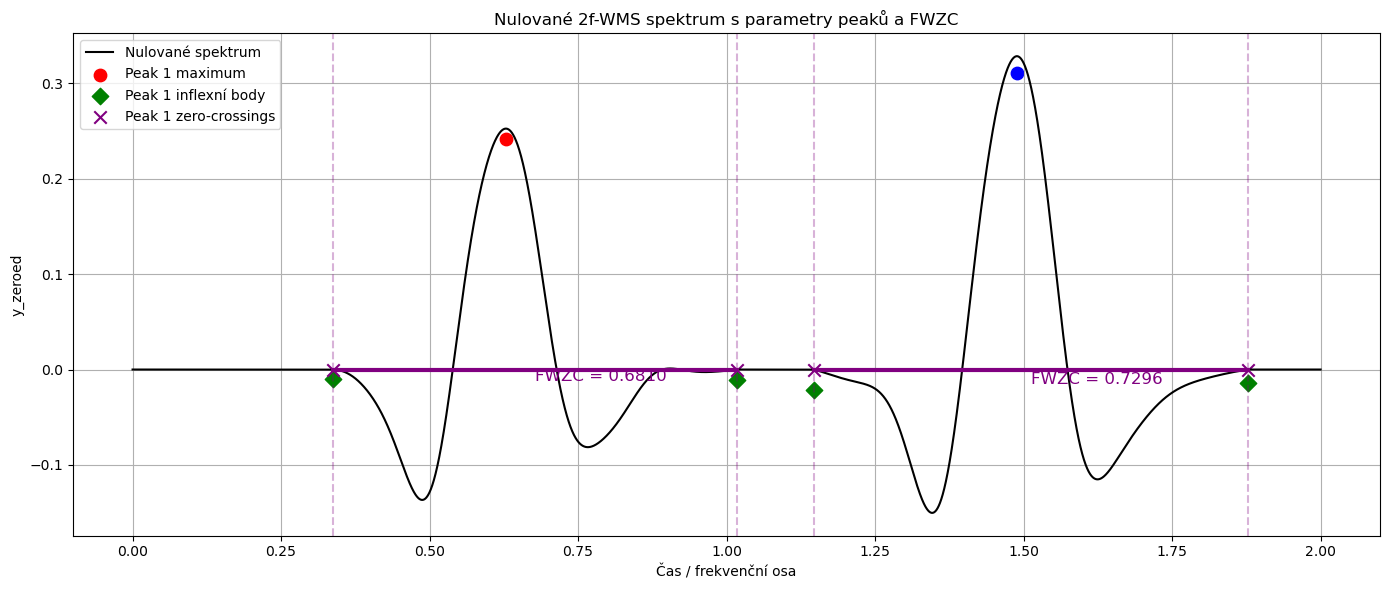

In [18]:
# ------------------------------------------------------------
# 1) Vytvoříme peak_data podle nového zero-crossing principu
# ------------------------------------------------------------

peak_data = []

# Helper: najde hodnotu y v analytickém výřezu
def y_at(x_local, y_local, x_target):
    idx = np.argmin(np.abs(x_local - x_target))
    return y_local[idx]

# Peak 1
x_local1 = g1_x
y_local1 = g1_y

p1_max_y = y_at(x_local1, y_local1, p1_max)

# minima (pokud existují)
p1_min_left  = np.nan
p1_min_right = np.nan

# inflexní body (pokud existují)
p1_inf_left  = p1_left
p1_inf_right = p1_right

# zero-crossing okraje
p1_zc_left  = p1_left
p1_zc_right = p1_right

# FWZC
p1_FWZC = p1_zc_right - p1_zc_left

# A2f_corr, H2f_corr — z analytického piku
p1_A2f_corr = np.max(y_local1)
p1_H2f_corr = p1_A2f_corr

peak_data.append([
    1,                 # peak_id
    p1_min_left,
    p1_min_right,
    p1_max,
    p1_inf_left,
    p1_inf_right,
    p1_A2f_corr,
    p1_H2f_corr,
    p1_zc_left,
    p1_zc_right,
    p1_FWZC
])

# Peak 2
x_local2 = g2_x
y_local2 = g2_y

p2_max_y = y_at(x_local2, y_local2, p2_max)

p2_min_left  = np.nan
p2_min_right = np.nan

p2_inf_left  = p2_left
p2_inf_right = p2_right

p2_zc_left  = p2_left
p2_zc_right = p2_right

p2_FWZC = p2_zc_right - p2_zc_left

p2_A2f_corr = np.max(y_local2)
p2_H2f_corr = p2_A2f_corr

peak_data.append([
    2,
    p2_min_left,
    p2_min_right,
    p2_max,
    p2_inf_left,
    p2_inf_right,
    p2_A2f_corr,
    p2_H2f_corr,
    p2_zc_left,
    p2_zc_right,
    p2_FWZC
])

print("peak_data created:")
for row in peak_data:
    print(row)


# ------------------------------------------------------------
# 2) Vizualizace nulovaného spektra + parametry peaků + FWZC
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.plot(xs, y_zeroed, label="Nulované spektrum", color="black")

colors = ["red", "blue"]  # Peak 1, Peak 2

for pid, row in enumerate(peak_data):
    peak_id = row[0]
    x_min_left, x_min_right = row[1], row[2]
    x_max = row[3]
    x_inf_left, x_inf_right = row[4], row[5]
    A2f_corr, H2f_corr = row[6], row[7]
    zc_left, zc_right = row[8], row[9]
    FWZC = row[10]

    col = colors[pid]

    # analytický výřez
    if pid == 0:
        x_local = g1_x
        y_local = g1_y
    else:
        x_local = g2_x
        y_local = g2_y

    # Maximum piku
    y_max = y_at(x_local, y_local, x_max)
    plt.scatter([x_max], [y_max], color=col, s=80, marker="o",
                label=f"Peak {peak_id} maximum" if pid == 0 else None)

    # Inflexní body
    y_inf_left  = y_at(x_local, y_local, x_inf_left)
    y_inf_right = y_at(x_local, y_local, x_inf_right)
    plt.scatter([x_inf_left, x_inf_right], [y_inf_left, y_inf_right],
                color="green", s=70, marker="D",
                label=f"Peak {peak_id} inflexní body" if pid == 0 else None)

    # Minima (pokud existují)
    if not np.isnan(x_min_left):
        y_ml = y_at(x_local, y_local, x_min_left)
        plt.scatter([x_min_left], [y_ml], color="orange", s=70, marker="v",
                    label=f"Peak {peak_id} minima" if pid == 0 else None)

    if not np.isnan(x_min_right):
        y_mr = y_at(x_local, y_local, x_min_right)
        plt.scatter([x_min_right], [y_mr], color="orange", s=70, marker="v")

    # Zero-crossing body
    if not np.isnan(zc_left):
        plt.scatter([zc_left], [0], color="purple", s=80, marker="x",
                    label=f"Peak {peak_id} zero-crossings" if pid == 0 else None)
        plt.axvline(zc_left, color="purple", linestyle="--", alpha=0.3)

    if not np.isnan(zc_right):
        plt.scatter([zc_right], [0], color="purple", s=80, marker="x")
        plt.axvline(zc_right, color="purple", linestyle="--", alpha=0.3)

    # FWZC vizualizace
    if not np.isnan(FWZC):
        plt.plot([zc_left, zc_right], [0, 0], color="purple", linewidth=3)
        plt.text((zc_left + zc_right)/2, -0.05 * H2f_corr,
                 f"FWZC = {FWZC:.4f}", color="purple", fontsize=12)

plt.title("Nulované 2f-WMS spektrum s parametry peaků a FWZC")
plt.xlabel("Čas / frekvenční osa")
plt.ylabel("y_zeroed")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
